In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
data = {
    "Name":["Alice","Bob","Claire", "Aman", "Riya",
            "Sneha", "Arjun","Priya","Rohan","Neha",
            "karan","Pooja","Vikas","Anjali","Ravi"],
    "Age":[25,30,27, 18,19,
           18, 21,22,19,23,
           21,25,30,27, 17],
    "Gender":["Female","Male","Female","Male","Male",
              "Female","Male","Female","Male","Male",
              "Female","Male","Female","Male","Male"],
    "Study_Hours":[2,4,5,1,6,
                   7,2,5,2,6,
                   8,3,7,1, 5],
    "Attenance":[90,75, 70,65,70,
                 90,75, 70,65,70,
                 90,75, 70,65,70],
    "Marks":[65,78,85,20,92,
             88,38,85,45, 65,
             95,33,85,25, 75]

}

# **Convert Age from Numerical to Categoical**

In [32]:
bins = [0,19,22,100]
labels = ["Teen", "Young Adult", "Adult"]
df["Age_Group"] = pd.cut(df["Age"],
                         bins=bins,
                         labels=labels)


In [34]:
df

,Name,Age,Gender,Study_Hours,Attenance,Marks,Age_Group
0,Alice,25,Female,2,90,65,Adult
1,Bob,30,Male,4,75,78,Adult
2,Claire,27,Female,5,70,85,Adult
3,Aman,18,Male,1,65,20,Teen
4,Riya,19,Male,6,70,92,Teen
5,Sneha,18,Female,7,90,88,Teen
6,Arjun,21,Male,2,75,38,Young Adult
7,Priya,22,Female,5,70,85,Young Adult
8,Rohan,19,Male,2,65,45,Teen
9,Neha,23,Male,6,70,65,Adult


In [28]:
df = pd.DataFrame(data)


In [30]:
df

,Name,Age,Gender,Study_Hours,Attenance,Marks
0,Alice,25,Female,2,90,65
1,Bob,30,Male,4,75,78
2,Claire,27,Female,5,70,85
3,Aman,18,Male,1,65,20
4,Riya,19,Male,6,70,92
5,Sneha,18,Female,7,90,88
6,Arjun,21,Male,2,75,38
7,Priya,22,Female,5,70,85
8,Rohan,19,Male,2,65,45
9,Neha,23,Male,6,70,65


In [10]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         15 non-null     object
 1   Age          15 non-null     int64 
 2   Gender       15 non-null     object
 3   Study_Hours  15 non-null     int64 
 4   Attenance    15 non-null     int64 
 5   Marks        15 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 852.0+ bytes


,Age,Study_Hours,Attenance,Marks
count,15.00000,15.000000,15.000000,15.000000
mean,22.80000,4.266667,74.000000,64.933333
std,4.34577,2.313521,8.904253,25.918737
min,17.00000,1.000000,65.000000,20.000000
25%,19.00000,2.000000,70.000000,41.500000
50%,22.00000,5.000000,70.000000,75.000000
75%,26.00000,6.000000,75.000000,85.000000
max,30.00000,8.000000,90.000000,95.000000


In [54]:
df["Result"] = np.where(df["Marks"] >=40, "Pass", "Fail")

In [13]:
df

,Name,Age,Gender,Study_Hours,Attenance,Marks,Result
0,Alice,25,Female,2,90,65,Pass
1,Bob,30,Male,4,75,78,Pass
2,Claire,27,Female,5,70,85,Pass
3,Aman,18,Male,1,65,20,Fail
4,Riya,19,Male,6,70,92,Pass
5,Sneha,18,Female,7,90,88,Pass
6,Arjun,21,Male,2,75,38,Fail
7,Priya,22,Female,5,70,85,Pass
8,Rohan,19,Male,2,65,45,Pass
9,Neha,23,Male,6,70,65,Pass


In [46]:
def performance_category(marks):
  if marks >=85:
    return "Excellent"
  elif marks >=70:
    return "Good"
  elif marks >= 50:
    return "Average"
  else:
    return "Poor"

In [47]:
df["Performance"] = df["Marks"].apply(performance_category)

In [48]:
df

,Name,Age,Gender,Study_Hours,Attenance,Marks,Age_Group,Performance
0,Alice,25,Female,2,90,65,Adult,Average
1,Bob,30,Male,4,75,78,Adult,Good
2,Claire,27,Female,5,70,85,Adult,Excellent
3,Aman,18,Male,1,65,20,Teen,Poor
4,Riya,19,Male,6,70,92,Teen,Excellent
5,Sneha,18,Female,7,90,88,Teen,Excellent
6,Arjun,21,Male,2,75,38,Young Adult,Poor
7,Priya,22,Female,5,70,85,Young Adult,Excellent
8,Rohan,19,Male,2,65,45,Teen,Poor
9,Neha,23,Male,6,70,65,Adult,Average


# **Categorical to Numerical**

In [18]:
from sklearn.preprocessing import LabelEncoder
data = ['Red','Green','Blue','Red','Green']
encoder = LabelEncoder()
encoded_data = encoder.fit_transform(data)
print(encoded_data)

[2 1 0 2 1]


In [24]:
from pandas.core.arrays import categorical
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
data = {'Employee_ID':[10,20,15,25,30],
        'Gender':['Male','Female','Male','Female','Male'],
        'Remarks':['Good','Nice','Good','Great','Nice']}
df = pd.DataFrame(data)
print("Original DataFrame:")
print(df)
categorical_columns = ['Gender','Remarks']
print("\nOne-Hot Encoding:")
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_columns])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_columns))
df = pd.concat([df, encoded_df], axis=1)

Original DataFrame:
   Employee_ID  Gender Remarks
0           10    Male    Good
1           20  Female    Nice
2           15    Male    Good
3           25  Female   Great
4           30    Male    Nice

One-Hot Encoding:


In [25]:
df

,Employee_ID,Gender,Remarks,Gender_Female,Gender_Male,Remarks_Good,Remarks_Great,Remarks_Nice
0,10,Male,Good,0.0,1.0,1.0,0.0,0.0
1,20,Female,Nice,1.0,0.0,0.0,0.0,1.0
2,15,Male,Good,0.0,1.0,1.0,0.0,0.0
3,25,Female,Great,1.0,0.0,0.0,1.0,0.0
4,30,Male,Nice,0.0,1.0,0.0,0.0,1.0


# **Univariate Analysis**

<Axes: xlabel='Age', ylabel='Count'>

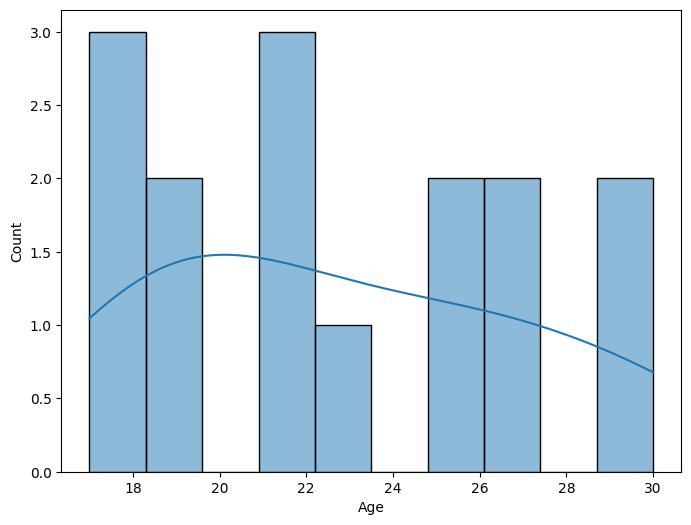

In [35]:
plt.figure(figsize=(8,6))
sns.histplot(df["Age"], bins=10, kde=True)

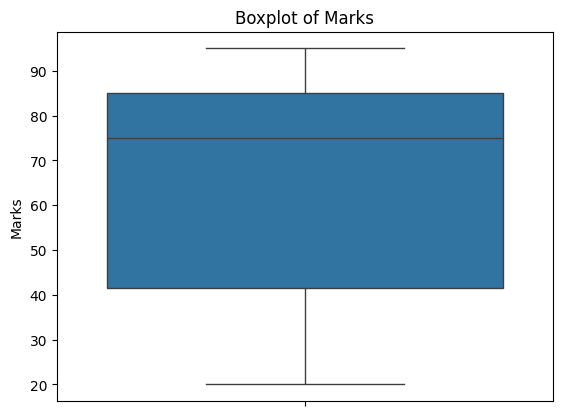

In [36]:
sns.boxplot(y=df["Marks"])
plt.title("Boxplot of Marks")
plt.show()

# **Statistical Measure**

In [38]:
print("Mean of Age:",df["Age"].mean())
print("Median of Age:",df["Age"].median())
print("Mode of Age:",df["Age"].mode())

Mean of Age: 22.8
Median of Age: 22.0
Mode of Age: 0    18
1    19
2    21
3    25
4    27
5    30
Name: Age, dtype: int64


# **Count Plot of categorical Data**

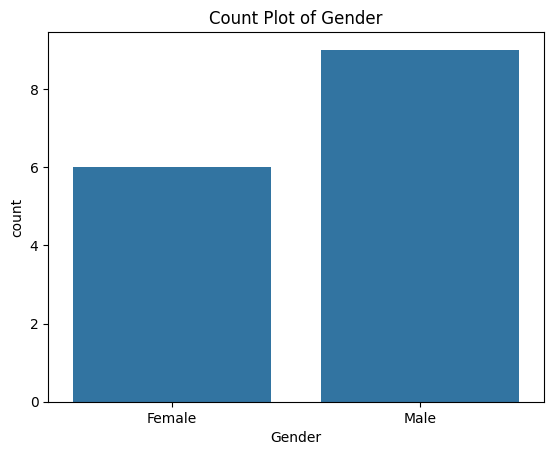

In [39]:
sns.countplot(data = df, x="Gender")
plt.title("Count Plot of Gender")
plt.show()

# **Bivariate Analysis**

Numerical vs. Numerical

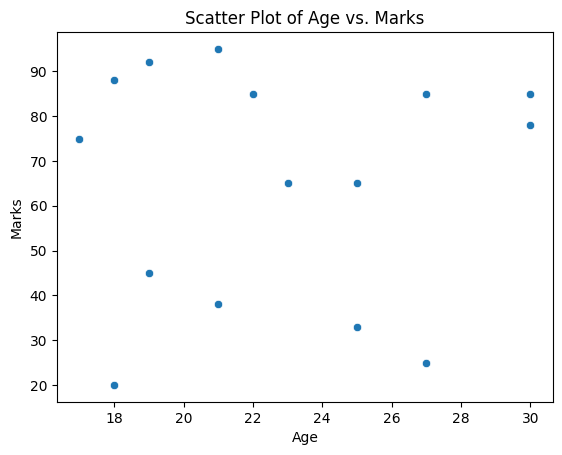

In [40]:
sns.scatterplot(x="Age", y="Marks", data=df)
plt.title("Scatter Plot of Age vs. Marks")
plt.show()
#

# **Correlation between two variable**

In [41]:
corr = df["Study_Hours"].corr(df["Marks"])
print("Correlation between Study_Hours and Marks:",corr)

Correlation between Study_Hours and Marks: 0.8746583092577053


# **Numerical vs. Categorical**

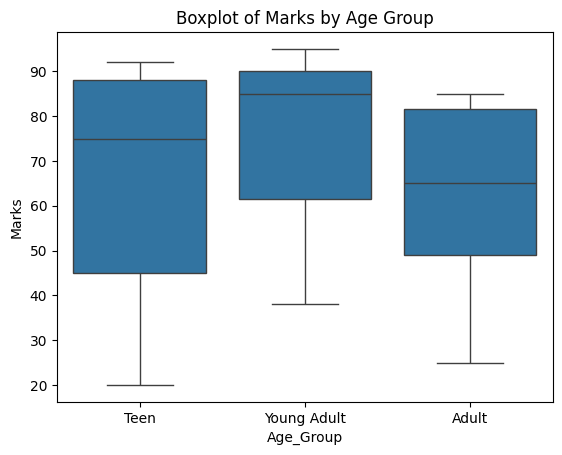

In [42]:
sns.boxplot(data=df,
            x="Age_Group",
            y="Marks")
plt.title("Boxplot of Marks by Age Group")
plt.show()
#

# **Categorical vs. categorical**

In [45]:
df

,Name,Age,Gender,Study_Hours,Attenance,Marks,Age_Group
0,Alice,25,Female,2,90,65,Adult
1,Bob,30,Male,4,75,78,Adult
2,Claire,27,Female,5,70,85,Adult
3,Aman,18,Male,1,65,20,Teen
4,Riya,19,Male,6,70,92,Teen
5,Sneha,18,Female,7,90,88,Teen
6,Arjun,21,Male,2,75,38,Young Adult
7,Priya,22,Female,5,70,85,Young Adult
8,Rohan,19,Male,2,65,45,Teen
9,Neha,23,Male,6,70,65,Adult


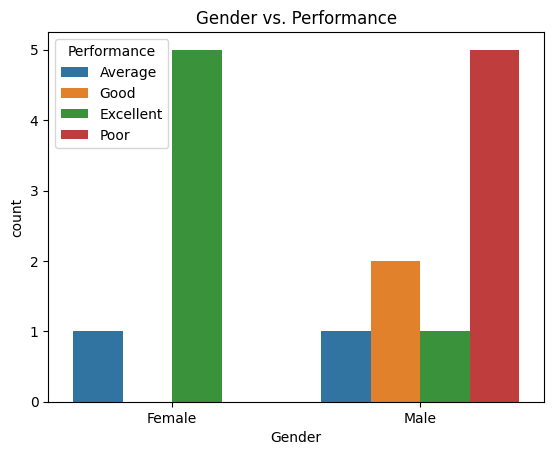

In [60]:
pd.crosstab(df["Gender"], df["Performance"])
sns.countplot(
    data=df,
    x="Gender",
    hue="Performance"
)
plt.title("Gender vs. Performance")
plt.show()


In [56]:
df

,Name,Age,Gender,Study_Hours,Attenance,Marks,Age_Group,Performance,Result
0,Alice,25,Female,2,90,65,Adult,Average,Pass
1,Bob,30,Male,4,75,78,Adult,Good,Pass
2,Claire,27,Female,5,70,85,Adult,Excellent,Pass
3,Aman,18,Male,1,65,20,Teen,Poor,Fail
4,Riya,19,Male,6,70,92,Teen,Excellent,Pass
5,Sneha,18,Female,7,90,88,Teen,Excellent,Pass
6,Arjun,21,Male,2,75,38,Young Adult,Poor,Fail
7,Priya,22,Female,5,70,85,Young Adult,Excellent,Pass
8,Rohan,19,Male,2,65,45,Teen,Poor,Pass
9,Neha,23,Male,6,70,65,Adult,Average,Pass


# **Multivariate Analysis**

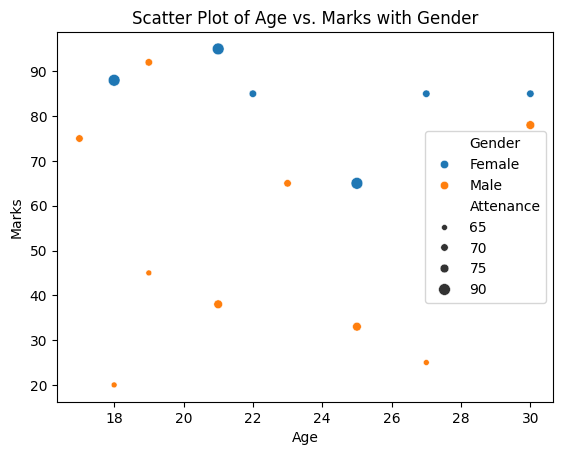

In [62]:
sns.scatterplot(data=df, x="Age", y="Marks", hue="Gender", size="Attenance")
plt.title("Scatter Plot of Age vs. Marks with Gender")
plt.show()

# **Pair Plot**

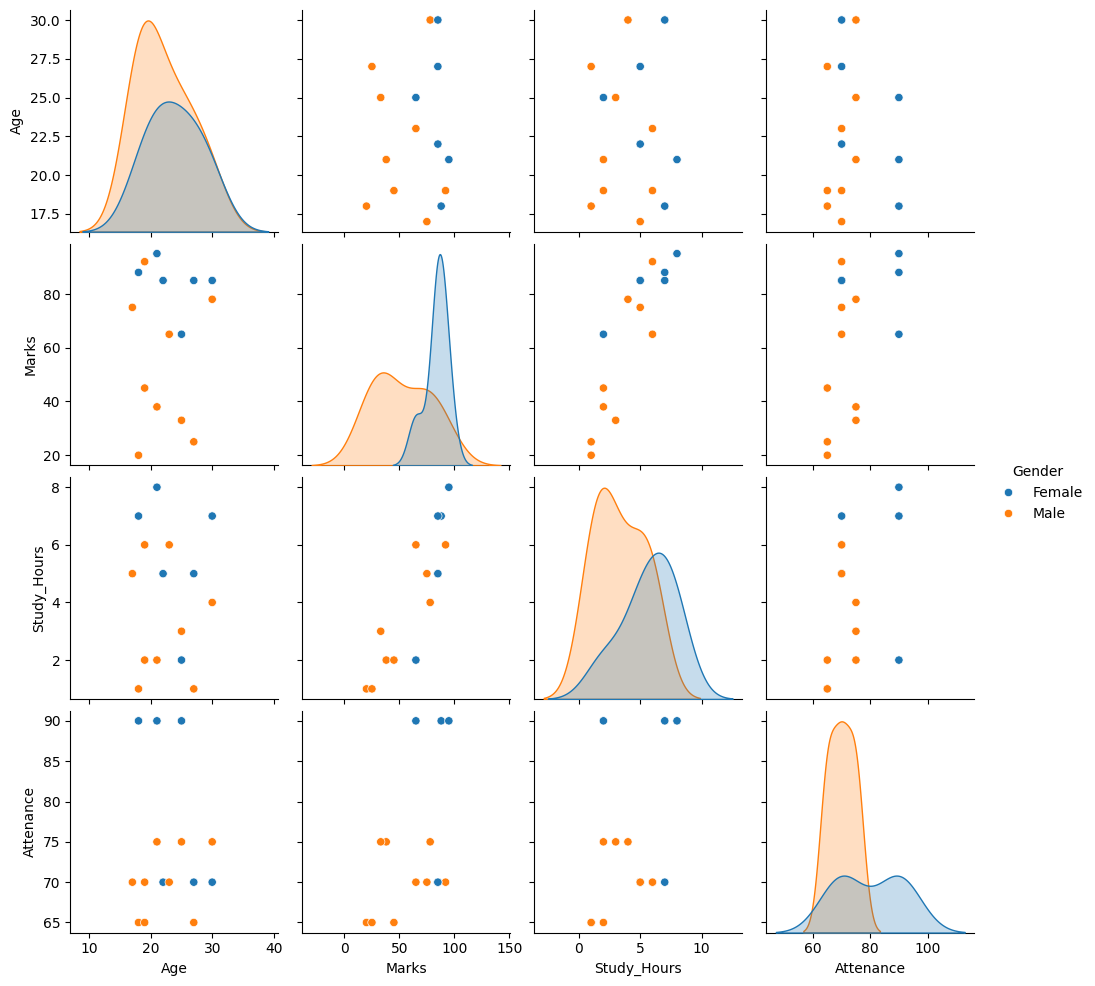

In [65]:
sns.pairplot(df, vars=["Age","Marks","Study_Hours","Attenance"], hue="Gender")
plt.show()

# **Correlation Heatmap**

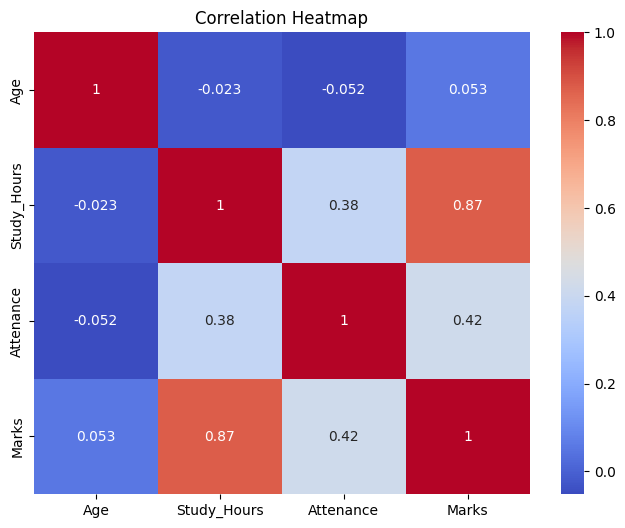

In [67]:
numeric_columns = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_columns.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()